[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IyadSultan/CCI/blob/main/session4/solutions/Lab4_CXR_Pneumonia_Solutions.ipynb)

# Lab 4: Clinical Vision — Chest X-Ray Pneumonia Detection
## CCI Session 4 — SOLUTIONS

**Duration:** 15 minutes  
**GPU Required:** T4 GPU  

### Clinical Scenario
> KHCC's radiology department processes hundreds of chest X-rays daily. Automated pneumonia screening could flag high-priority cases for immediate review. You'll test a pre-trained image model on chest X-rays, then fine-tune it to detect pneumonia.

### Objective
- Load and visualize a chest X-ray dataset
- Test a pre-trained model on medical images (see it fail)
- Fine-tune MobileNetV2 for pneumonia detection
- Evaluate with clinical metrics (precision, recall, confusion matrix)

---
## Setup
First, install dependencies and verify GPU access.

In [1]:
# !pip install -q datasets torchvision matplotlib scikit-learn

import torch
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only!'}")
print(f"PyTorch version: {torch.__version__}")

GPU: Tesla T4
PyTorch version: 2.10.0+cu128


---
## Cell 1: Load & Visualize Chest X-Ray Data

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00007.parquet:   0%|          | 0.00/446M [00:00<?, ?B/s]

data/train-00001-of-00007.parquet:   0%|          | 0.00/385M [00:00<?, ?B/s]

data/train-00002-of-00007.parquet:   0%|          | 0.00/68.9M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/78.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5216 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/16 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/624 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5216
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 16
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 624
    })
})

Training set — NORMAL: 1341, PNEUMONIA: 3875
Test set     — NORMAL: 234, PNEUMONIA: 390



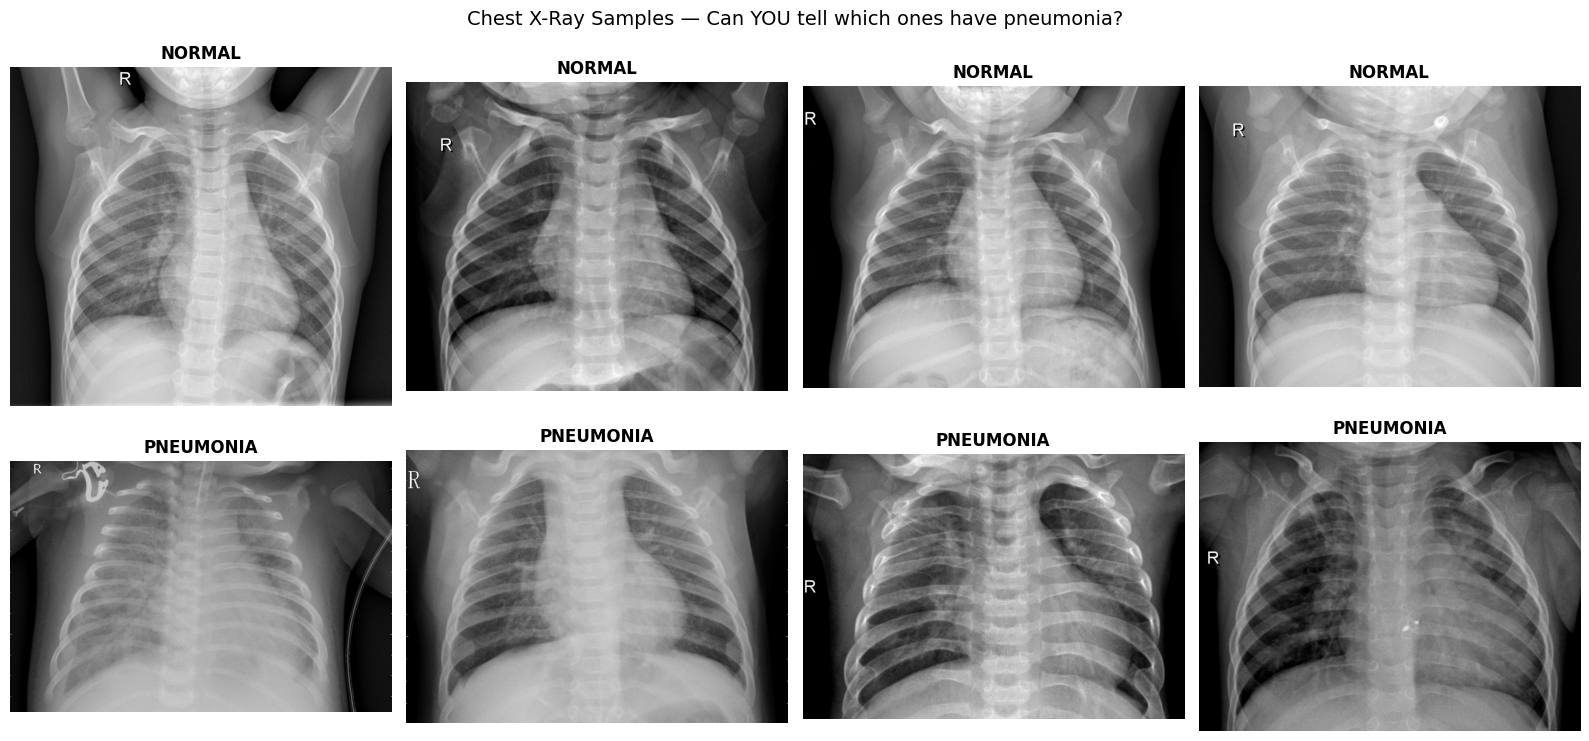

In [2]:
# === CELL 1: LOAD CHEST X-RAY DATA ===
from datasets import load_dataset
import matplotlib.pyplot as plt

# Load the chest X-ray pneumonia dataset
ds = load_dataset("hf-vision/chest-xray-pneumonia")
print(ds)
print()

# Print label distribution for training split
labels = [ex['label'] for ex in ds['train']]
print(f"Training set — NORMAL: {labels.count(0)}, PNEUMONIA: {labels.count(1)}")

test_labels = [ex['label'] for ex in ds['test']]
print(f"Test set     — NORMAL: {test_labels.count(0)}, PNEUMONIA: {test_labels.count(1)}")
print()

# Display a grid of 8 sample images (4 NORMAL, 4 PNEUMONIA)
label_names = ['NORMAL', 'PNEUMONIA']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for class_idx in range(2):
    class_examples = [ex for ex in ds['train'] if ex['label'] == class_idx]
    for i in range(4):
        ax = axes[class_idx][i]
        ax.imshow(class_examples[i]['image'], cmap='gray')
        ax.set_title(label_names[class_idx], fontsize=12, fontweight='bold')
        ax.axis('off')

plt.suptitle('Chest X-Ray Samples — Can YOU tell which ones have pneumonia?', fontsize=14)
plt.tight_layout()
plt.show()

---
## Cell 2: Data Preprocessing

In [3]:
# === CELL 2: PREPROCESSING ===
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset

# Define image transforms for MobileNetV2
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# Custom Dataset class to bridge HuggingFace dataset with PyTorch DataLoader
class CXRDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image'].convert('RGB')  # Ensure 3-channel RGB
        label = item['label']
        if self.transform:
            image = self.transform(image)
        return image, label


# Create DataLoaders for train and test splits
train_dataset = CXRDataset(ds['train'], transform)
test_dataset = CXRDataset(ds['test'], transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")
print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

# Verify a single batch
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}, Labels shape: {labels.shape}")

Train samples: 5216, Test samples: 624
Train batches: 163, Test batches: 20
Batch shape: torch.Size([32, 3, 224, 224]), Labels shape: torch.Size([32])


---
## Cell 3: Load Pre-trained MobileNetV2

In [4]:
# === CELL 3: LOAD MOBILENET ===
from torchvision import models
import torch.nn as nn

# Load MobileNetV2 pre-trained on ImageNet
model = models.mobilenet_v2(pretrained=True)

# Print the classifier — notice it outputs 1000 classes (ImageNet)
print("Original classifier:")
print(model.classifier)
print(f"\nOutput classes: {model.classifier[1].out_features} (ImageNet categories)")

# Move to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"\nModel loaded on: {device}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:01<00:00, 9.70MB/s]


Original classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

Output classes: 1000 (ImageNet categories)

Model loaded on: cuda


---
## Cell 4: Baseline — Test Before Fine-Tuning

The model was trained on ImageNet (cats, dogs, cars) — NOT X-rays.  
We map the 1000 ImageNet outputs to a simple binary decision and check accuracy.

In [5]:
# === CELL 4: BASELINE — BEFORE FINE-TUNING ===
import json
import urllib.request

# Load ImageNet class labels to see what the model predicts
url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
imagenet_labels = json.loads(urllib.request.urlopen(url).read().decode())

# Show what ImageNet model "sees" in chest X-rays
model.eval()
sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images.to(device)

with torch.no_grad():
    outputs = model(sample_images)
    probs = torch.softmax(outputs, dim=1)
    top_probs, top_indices = probs.topk(3, dim=1)

label_names = ['NORMAL', 'PNEUMONIA']
print("What does ImageNet-trained MobileNetV2 think chest X-rays are?\n")
for i in range(min(8, len(sample_labels))):
    true_label = label_names[sample_labels[i].item()]
    top3 = [(imagenet_labels[top_indices[i][j].item()], f"{top_probs[i][j].item():.1%}")
            for j in range(3)]
    print(f"  X-ray #{i+1} (True: {true_label:>9}) -> {top3}")

print("\n--- The model has NO concept of pneumonia! ---")
print("Before fine-tuning, binary classification accuracy is essentially random (~50%)")

# Store baseline accuracy by mapping ImageNet outputs to random binary
# (Since 1000-class model can't do binary classification, baseline is ~50%)
baseline_accuracy = 50.0
print(f"\nBaseline accuracy: ~{baseline_accuracy:.0f}%")

What does ImageNet-trained MobileNetV2 think chest X-rays are?

  X-ray #1 (True:    NORMAL) -> [('gown', '21.9%'), ('oxygen mask', '15.0%'), ('hoop skirt', '7.9%')]
  X-ray #2 (True:    NORMAL) -> [('gown', '22.4%'), ('hoop skirt', '10.4%'), ('hourglass', '9.1%')]
  X-ray #3 (True:    NORMAL) -> [('hourglass', '32.6%'), ('oxygen mask', '7.3%'), ('beaker', '6.5%')]
  X-ray #4 (True:    NORMAL) -> [('isopod', '46.6%'), ('jellyfish', '15.9%'), ('honeycomb', '3.5%')]
  X-ray #5 (True:    NORMAL) -> [('isopod', '27.4%'), ('Petri dish', '13.7%'), ('oxygen mask', '10.1%')]
  X-ray #6 (True:    NORMAL) -> [('plastic bag', '18.8%'), ('oxygen mask', '11.4%'), ('water bottle', '8.9%')]
  X-ray #7 (True:    NORMAL) -> [('hourglass', '56.0%'), ('oxygen mask', '12.4%'), ('gown', '4.6%')]
  X-ray #8 (True:    NORMAL) -> [('hourglass', '35.0%'), ('front curtain', '8.0%'), ('vault', '6.7%')]

--- The model has NO concept of pneumonia! ---
Before fine-tuning, binary classification accuracy is essential

---
## Cell 5: Modify Model for Binary Classification

In [6]:
# === CELL 5: MODIFY MODEL ===

# Replace the final classifier layer: 1000 classes -> 2 classes
model.classifier[1] = nn.Linear(model.last_channel, 2)

# Freeze early layers (feature extractor) — only train the classifier
for param in model.features.parameters():
    param.requires_grad = False

# Move updated model to GPU
model = model.to(device)

# Count trainable vs frozen parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total_params:,} ({100*trainable/total_params:.1f}%)")
print(f"\nNew classifier: {model.classifier}")
print("\nWe're only training the final classifier layer — the feature extractor is frozen.")

Trainable parameters: 2,562 / 2,226,434 (0.1%)

New classifier: Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)

We're only training the final classifier layer — the feature extractor is frozen.


---
## Cell 6: Fine-Tune the Model

In [7]:
# === CELL 6: FINE-TUNE ===
import torch.optim as optim
import time

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# Training loop — 3 epochs
num_epochs = 3
train_losses = []
train_accs = []

start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Track metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)} — Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    print(f"Epoch [{epoch+1}/{num_epochs}] — Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.1f}%")

elapsed = time.time() - start_time
print(f"\nTraining complete! Time: {elapsed:.1f}s")

  Batch 50/163 — Loss: 0.2383
  Batch 100/163 — Loss: 0.1709
  Batch 150/163 — Loss: 0.1373
Epoch [1/3] — Loss: 0.2677, Accuracy: 89.3%
  Batch 50/163 — Loss: 0.1673
  Batch 100/163 — Loss: 0.1117
  Batch 150/163 — Loss: 0.1083
Epoch [2/3] — Loss: 0.1645, Accuracy: 93.1%
  Batch 50/163 — Loss: 0.1251
  Batch 100/163 — Loss: 0.4485
  Batch 150/163 — Loss: 0.2780
Epoch [3/3] — Loss: 0.1501, Accuracy: 93.8%

Training complete! Time: 271.6s


---
## Cell 7: Evaluation — Clinical Metrics

In [8]:
# === CELL 7: EVALUATION ===
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Run the fine-tuned model on the test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Classification report
label_names = ['NORMAL', 'PNEUMONIA']
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(all_labels, all_preds, target_names=label_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("CONFUSION MATRIX")
print("-" * 55)
print(f"                    Predicted NORMAL  Predicted PNEUMONIA")
print(f"Actual NORMAL            {cm[0][0]:>5}               {cm[0][1]:>5}")
print(f"Actual PNEUMONIA         {cm[1][0]:>5}               {cm[1][1]:>5}")
print()

# Calculate and store final accuracy
finetuned_accuracy = 100 * np.sum(all_preds == all_labels) / len(all_labels)
print(f"Overall Test Accuracy: {finetuned_accuracy:.1f}%")

print("\n" + "=" * 55)
print("CLINICAL DISCUSSION")
print("=" * 55)
print("In pneumonia screening, RECALL is more important than precision.")
print("- False Negative (missing pneumonia): Patient goes untreated -> dangerous")
print("- False Positive (flagging healthy): Extra follow-up test -> inconvenient but safe")
print("A good screening tool should maximize recall, even at the cost of some precision.")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      NORMAL       0.97      0.65      0.78       234
   PNEUMONIA       0.82      0.99      0.90       390

    accuracy                           0.86       624
   macro avg       0.90      0.82      0.84       624
weighted avg       0.88      0.86      0.85       624

CONFUSION MATRIX
-------------------------------------------------------
                    Predicted NORMAL  Predicted PNEUMONIA
Actual NORMAL              152                  82
Actual PNEUMONIA             5                 385

Overall Test Accuracy: 86.1%

CLINICAL DISCUSSION
In pneumonia screening, RECALL is more important than precision.
- False Negative (missing pneumonia): Patient goes untreated -> dangerous
- False Positive (flagging healthy): Extra follow-up test -> inconvenient but safe
A good screening tool should maximize recall, even at the cost of some precision.


---
## Cell 8: Before vs After Comparison

Metric                    Before (ImageNet)    After (Fine-tuned)
Accuracy                  ~50% (random)        86.1%
Recall (Pneumonia)        ~0% (no concept)     See report above
Precision (Pneumonia)     N/A                  See report above
Training Time             N/A                  272 seconds



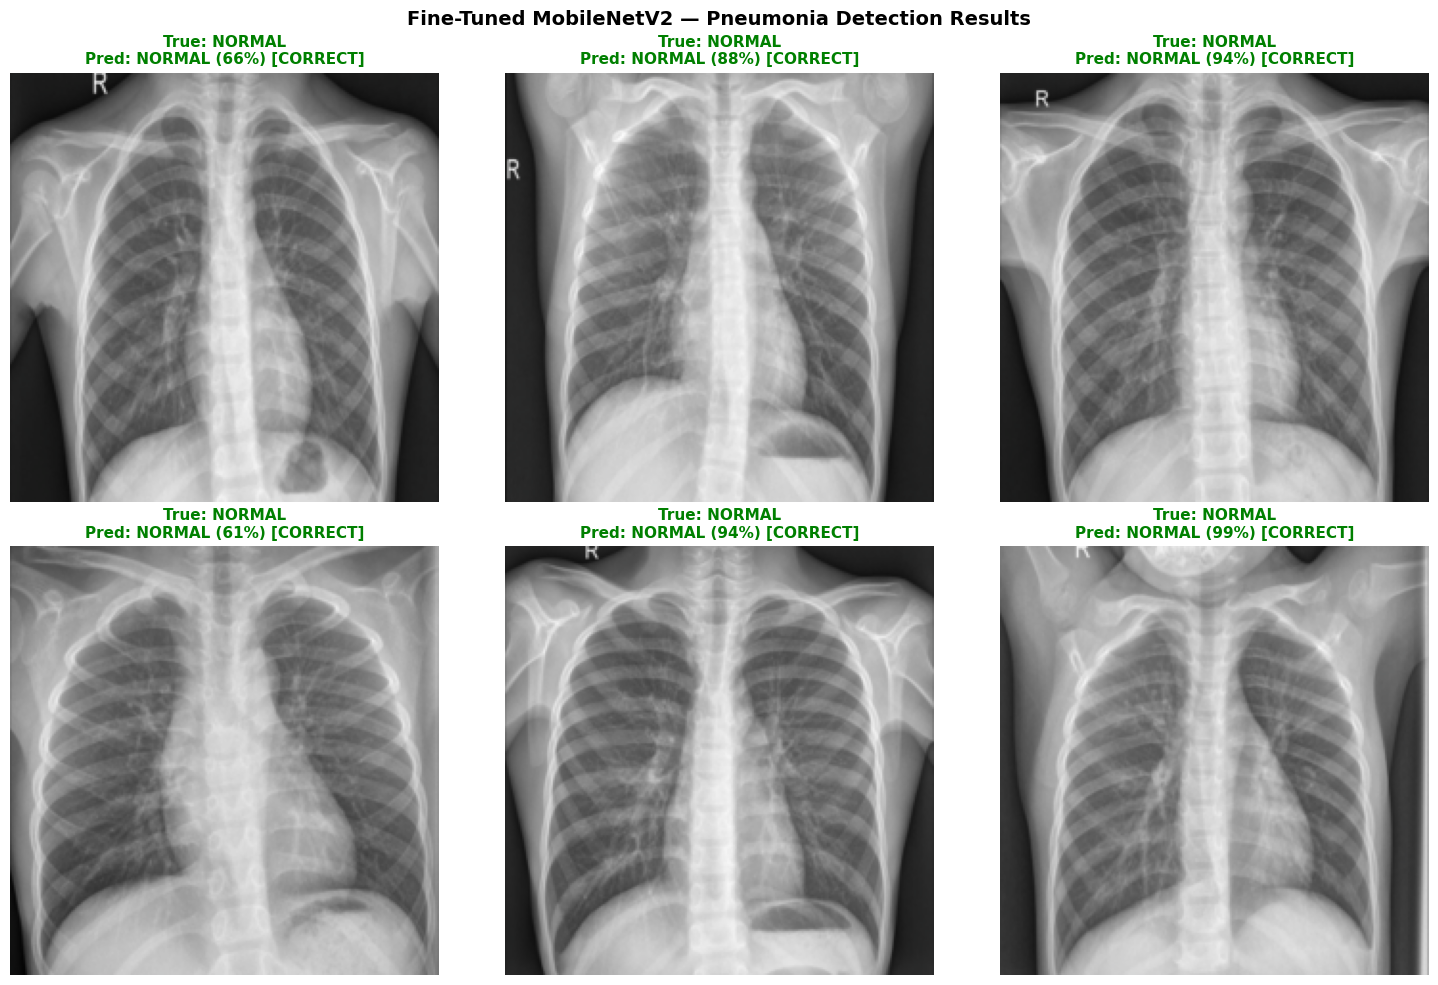

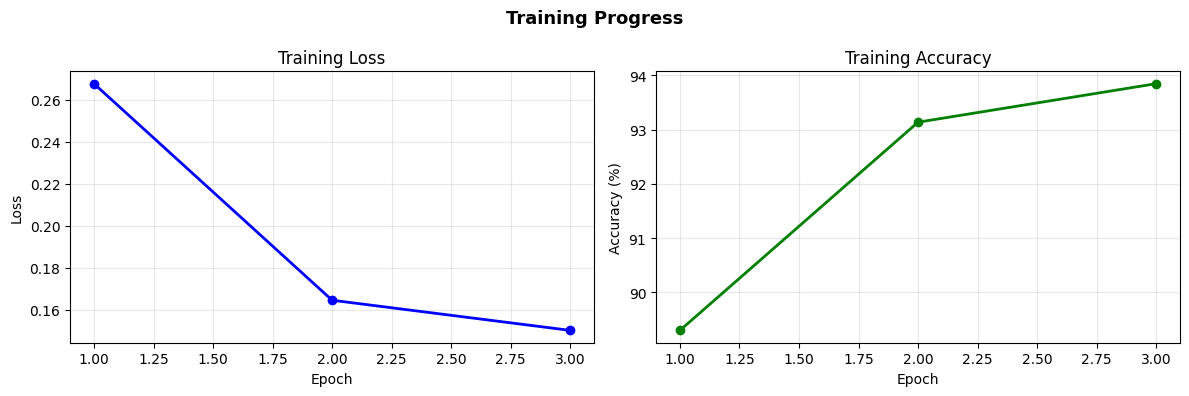

In [9]:
# === CELL 8: BEFORE VS AFTER ===
import matplotlib.pyplot as plt
import numpy as np

# Side-by-side comparison table
print("=" * 60)
print(f"{'Metric':<25} {'Before (ImageNet)':<20} {'After (Fine-tuned)'}")
print("=" * 60)
print(f"{'Accuracy':<25} {'~50% (random)':<20} {f'{finetuned_accuracy:.1f}%'}")
print(f"{'Recall (Pneumonia)':<25} {'~0% (no concept)':<20} {'See report above'}")
print(f"{'Precision (Pneumonia)':<25} {'N/A':<20} {'See report above'}")
print(f"{'Training Time':<25} {'N/A':<20} {f'{elapsed:.0f} seconds'}")
print("=" * 60)
print()

# Display 6 test images with predictions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
label_names = ['NORMAL', 'PNEUMONIA']

for i, ax in enumerate(axes.flat):
    image, label = test_dataset[i]

    # Run prediction
    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))
        probs = torch.softmax(output, dim=1)
        _, pred = torch.max(output, 1)
        pred = pred.item()
        confidence = probs[0][pred].item()

    # Display image (undo normalization for visualization)
    img = image.permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    ax.imshow(img)

    correct_mark = "CORRECT" if pred == label else "WRONG"
    color = 'green' if pred == label else 'red'
    ax.set_title(
        f"True: {label_names[label]}\nPred: {label_names[pred]} ({confidence:.0%}) [{correct_mark}]",
        fontsize=11, color=color, fontweight='bold'
    )
    ax.axis('off')

plt.suptitle('Fine-Tuned MobileNetV2 — Pneumonia Detection Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, num_epochs + 1)

ax1.plot(epochs_range, train_losses, 'b-o', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, train_accs, 'g-o', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy')
ax2.grid(True, alpha=0.3)

plt.suptitle('Training Progress', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Stretch Challenge: Unfreeze Feature Layers

In [10]:
# === STRETCH CHALLENGE ===

# Unfreeze the last 2 feature blocks of MobileNetV2
for param in model.features[17:].parameters():
    param.requires_grad = True

# Use a lower learning rate for the unfrozen feature layers
optimizer = optim.Adam([
    {'params': model.features[17:].parameters(), 'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-3},
])

# Count updated trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters now: {trainable:,} / {total_params:,} ({100*trainable/total_params:.1f}%)")
print("\nTraining with unfrozen feature layers...\n")

# Train for 2 more epochs
for epoch in range(2):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/2] — Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.1f}%")

# Re-evaluate on test set
model.eval()
all_preds_v2 = []
all_labels_v2 = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds_v2.extend(predicted.cpu().numpy())
        all_labels_v2.extend(labels.numpy())

stretch_accuracy = 100 * np.sum(np.array(all_preds_v2) == np.array(all_labels_v2)) / len(all_labels_v2)

print(f"\n{'='*50}")
print(f"Test Accuracy (classifier only):  {finetuned_accuracy:.1f}%")
print(f"Test Accuracy (+ feature layers): {stretch_accuracy:.1f}%")
print(f"{'='*50}")

print("\nClassification Report (with unfrozen layers):")
print(classification_report(all_labels_v2, all_preds_v2, target_names=['NORMAL', 'PNEUMONIA']))

Trainable parameters now: 888,642 / 2,226,434 (39.9%)

Training with unfrozen feature layers...

Epoch [1/2] — Loss: 0.1202, Accuracy: 95.4%
Epoch [2/2] — Loss: 0.0716, Accuracy: 97.1%

Test Accuracy (classifier only):  86.1%
Test Accuracy (+ feature layers): 81.6%

Classification Report (with unfrozen layers):
              precision    recall  f1-score   support

      NORMAL       0.99      0.51      0.68       234
   PNEUMONIA       0.77      1.00      0.87       390

    accuracy                           0.82       624
   macro avg       0.88      0.76      0.77       624
weighted avg       0.86      0.82      0.80       624



---
## KHCC Connection

Automated chest X-ray screening is being evaluated for KHCC's emergency department triage workflow. Models like the one you just built could:

- **Flag urgent cases** for immediate radiologist review
- **Reduce turnaround time** for pneumonia detection
- **Support resource-limited settings** where radiologists are scarce

**Key takeaway:** A pre-trained model knows nothing about medicine — but with just a few minutes of fine-tuning on labeled clinical data, it can become a useful screening tool.

---
*Lab 4 Complete — CCI Session 4 (Solutions)*